## Import

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def seed(seed:int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
seed(42)
device=torch.device('cuda')

## Load Data

In [2]:
BASE_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'classify-leaves').exists())
DATA_DIR = BASE_DIR / 'data' / 'classify-leaves'
IMAGE_DIR= BASE_DIR / 'data' / 'classify-leaves' / 'images'

df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_test = pd.read_csv(DATA_DIR / 'test.csv')
df_train.describe()

,image,label
count,18353,18353
unique,18353,176
top,images/0.jpg,maclura_pomifera
freq,1,353


In [3]:
def resolve_image_path(image_feature):
    image_name = Path(image_feature).name
    image_path = IMAGE_DIR / image_name
    if not image_path.exists():
        raise FileNotFoundError(f'Image not found: {image_path}')
    return image_path

df_train['image_path'] = df_train['image'].apply(resolve_image_path)
df_test['image_path'] = df_test['image'].apply(resolve_image_path)

df_train[['image', 'image_path', 'label']].head()

,image,image_path,label
0,images/0.jpg,d:\deeplearning\Project\data\classify-leaves\i...,maclura_pomifera
1,images/1.jpg,d:\deeplearning\Project\data\classify-leaves\i...,maclura_pomifera
2,images/2.jpg,d:\deeplearning\Project\data\classify-leaves\i...,maclura_pomifera
3,images/3.jpg,d:\deeplearning\Project\data\classify-leaves\i...,maclura_pomifera
4,images/4.jpg,d:\deeplearning\Project\data\classify-leaves\i...,maclura_pomifera


## Data Analysis

### (1) Structure

In [4]:
print('train shape:',df_train.shape)
print('test shape:',df_test.shape)
print('num classes:',df_train['label'].nunique())

print('duplicate train images:', df_train['image'].duplicated().sum())
print('duplicate test images:', df_test['image'].duplicated().sum())

train shape: (18353, 3)
test shape: (8800, 2)
num classes: 176
duplicate train images: 0
duplicate test images: 0


### (2) class distribution

In [5]:
class_counts=df_train['label'].value_counts()
print(class_counts.describe())
print('\nTop 10 classes:',class_counts.head(10))

print('\nBottom 10 classes',class_counts.tail(10))

count    176.000000
mean     104.278409
std       38.672350
min       51.000000
25%       80.000000
50%       98.000000
75%      109.250000
max      353.000000
Name: count, dtype: float64

Top 10 classes: label
maclura_pomifera            353
ulmus_rubra                 235
prunus_virginiana           223
acer_rubrum                 217
broussonettia_papyrifera    214
prunus_sargentii            209
ptelea_trifoliata           193
ulmus_pumila                189
abies_concolor              176
asimina_triloba             174
Name: count, dtype: int64

Bottom 10 classes label
aesculus_flava          68
amelanchier_arborea     68
pinus_thunbergii        67
acer_griseum            64
ulmus_procera           58
cedrus_deodara          58
ailanthus_altissima     58
crataegus_crus-galli    54
evodia_daniellii        53
juniperus_virginiana    51
Name: count, dtype: int64


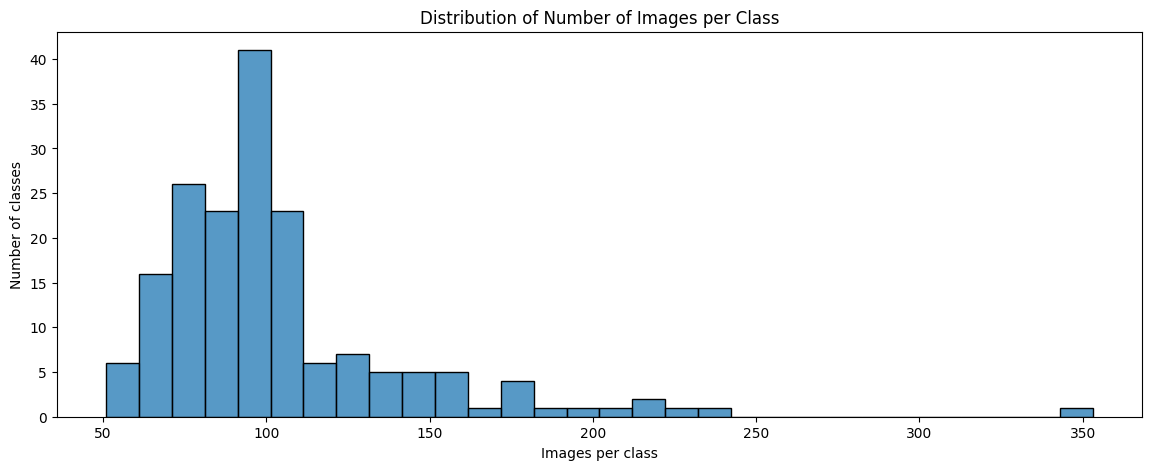

In [6]:
plt.figure(figsize=(14, 5))
sns.histplot(class_counts, bins=30)
plt.title('Distribution of Number of Images per Class')
plt.xlabel('Images per class')
plt.ylabel('Number of classes')
plt.show()

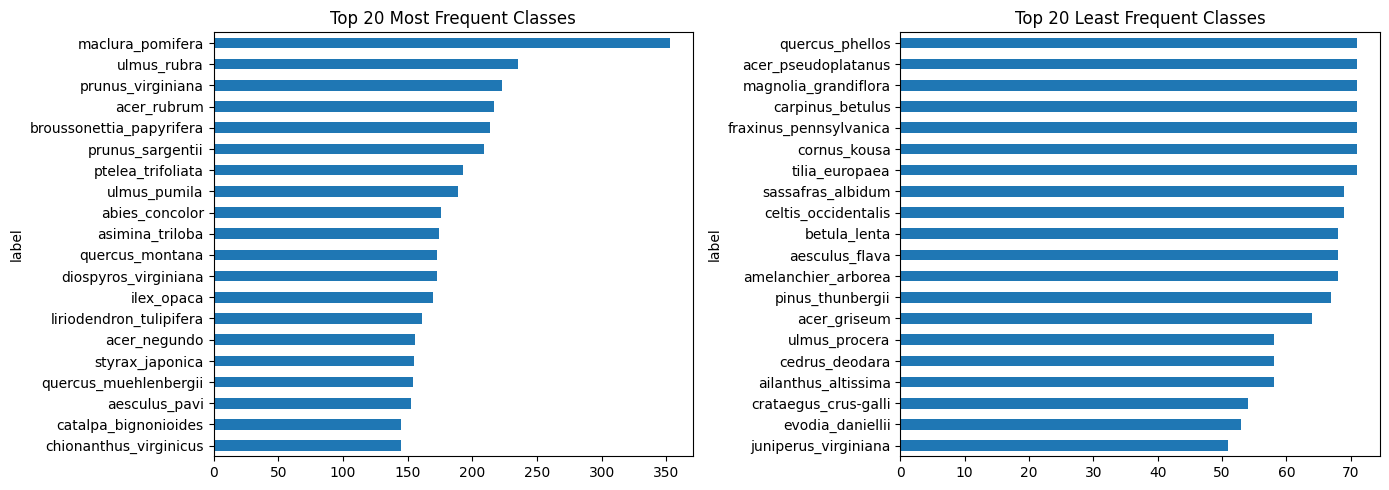

In [12]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

class_counts.head(20).sort_values().plot(kind='barh',ax=axes[0])
axes[0].set_title('Top 20 Most Frequent Classes')

class_counts.tail(20).sort_values().plot(kind='barh',ax=axes[1])
axes[1].set_title('Top 20 Least Frequent Classes')

plt.tight_layout()
plt.show()

### (3) check missing path

In [13]:
missing_train = df_train[~df_train['image_path'].apply(lambda p: p.exists())]
missing_test = df_test[~df_test['image_path'].apply(lambda p: p.exists())]

print('missing train images:', len(missing_train))
print('missing test images:', len(missing_test))

missing train images: 0
missing test images: 0


### (4) img size & format

In [14]:
from PIL import Image
def get_image_info(path):
    with Image.open(path) as img:
        return pd.Series({
            'width': img.width,
            'height': img.height,
            'mode': img.mode,
            'format': img.format,
            'aspect_ratio': img.width/img.height
        })
image_info=df_train['image_path'].apply(get_image_info)
df_train_info=pd.concat([df_train,image_info],axis=1)
df_train_info[['width','height','aspect_ratio']].describe()

,width,height,aspect_ratio
count,18353.0,18353.0,18353.0
mean,224.0,224.0,1.0
std,0.0,0.0,0.0
min,224.0,224.0,1.0
25%,224.0,224.0,1.0
50%,224.0,224.0,1.0
75%,224.0,224.0,1.0
max,224.0,224.0,1.0


### (5) random sample

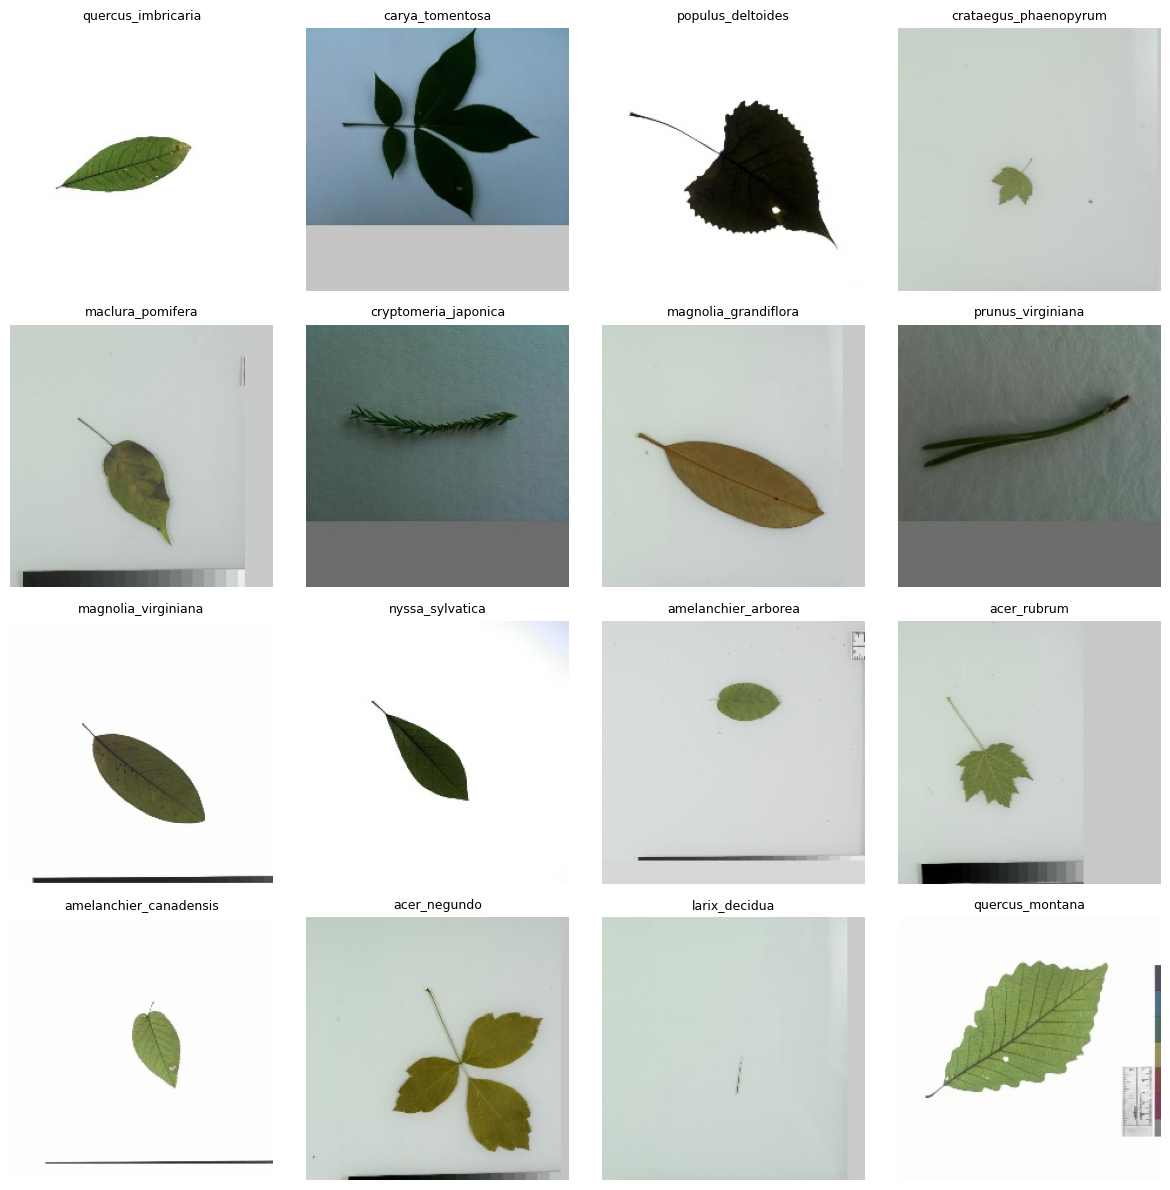

In [22]:
def show_samples(df, n=16, seed=42):
    sample_df = df.sample(n, random_state=seed)
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(12, 3 * rows))
    for i, (_, row) in enumerate(sample_df.iterrows(), 1):
        img = Image.open(row['image_path'])
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(row['label'], fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(df_train, n=16)

### (6) Rare class

cedrus_deodara count: 58


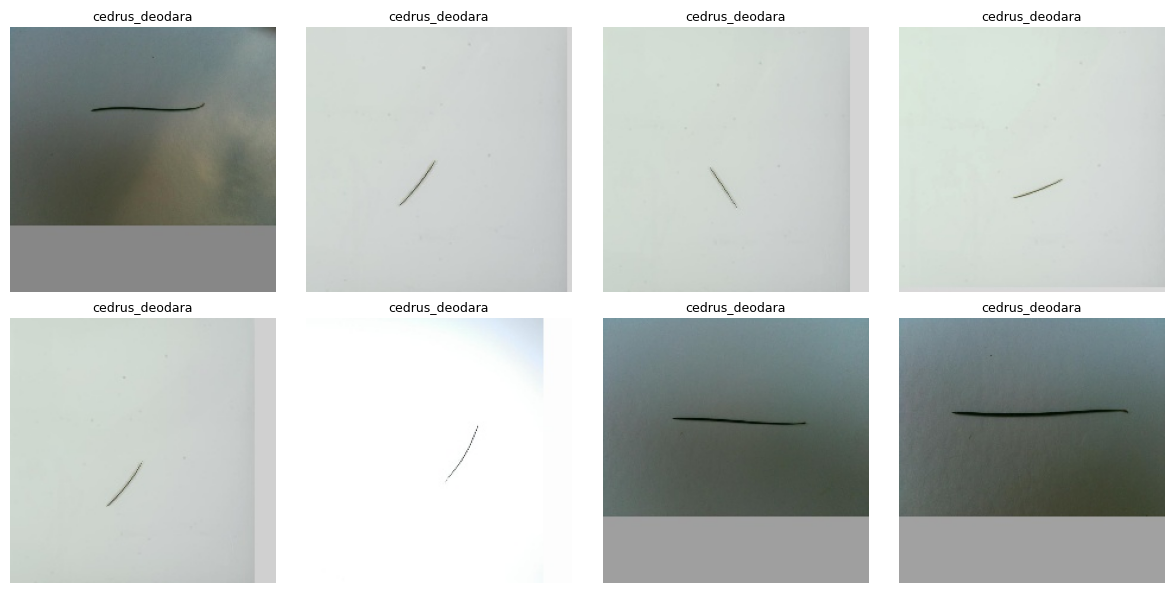

ailanthus_altissima count: 58


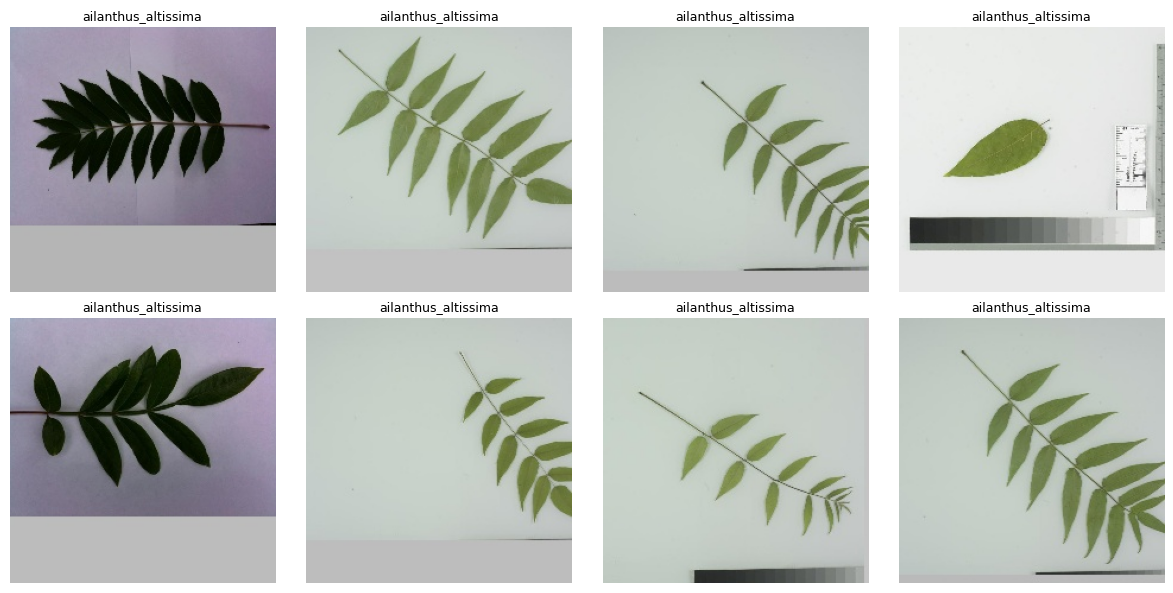

crataegus_crus-galli count: 54


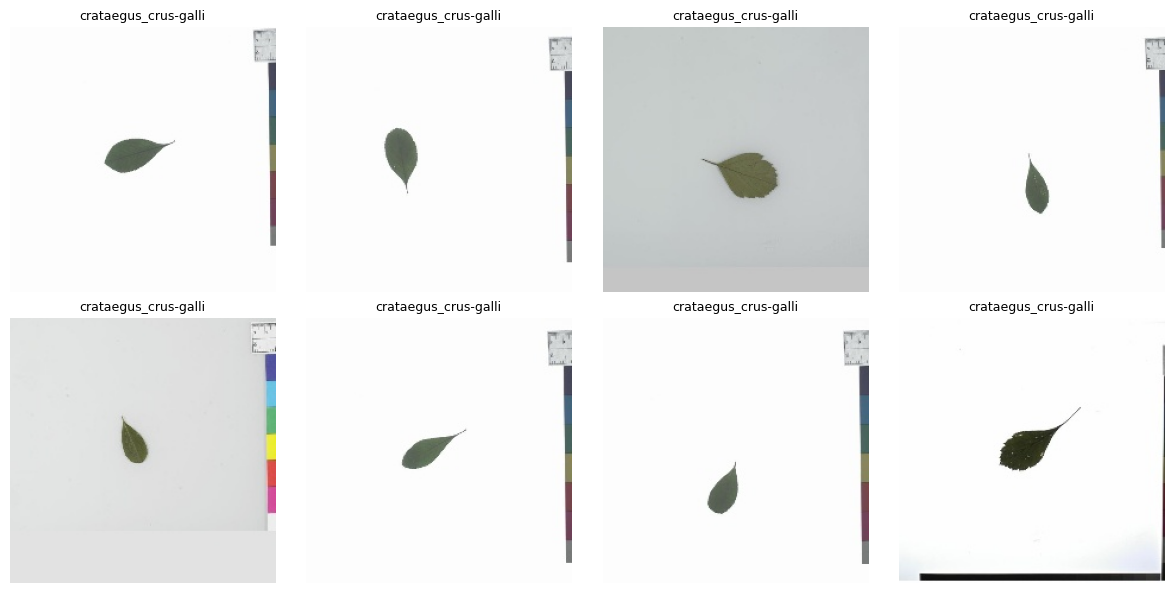

evodia_daniellii count: 53


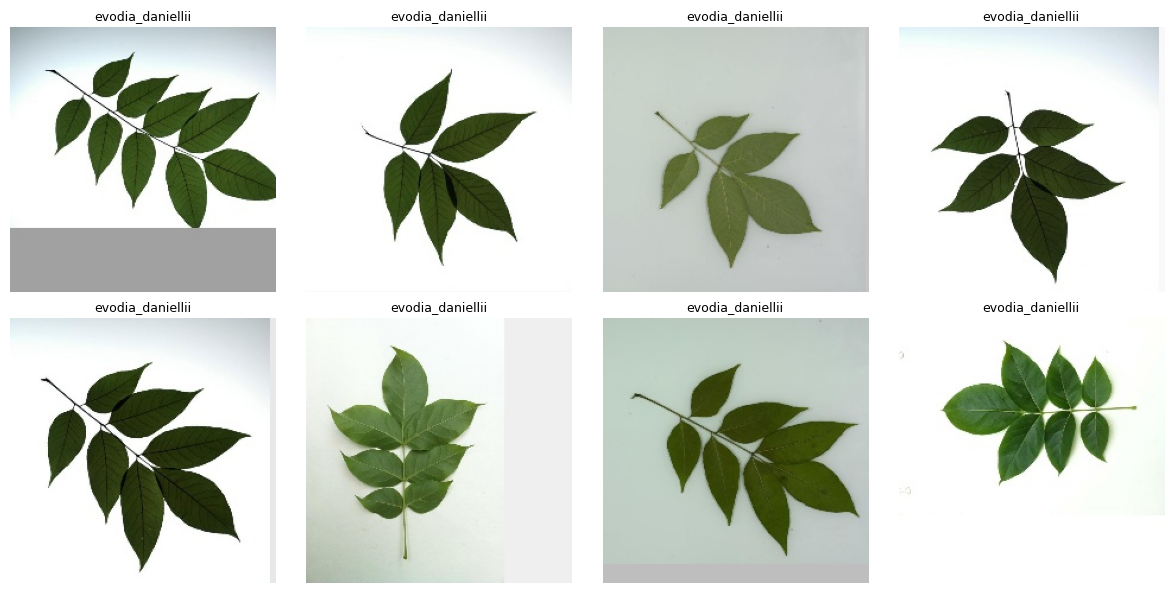

juniperus_virginiana count: 51


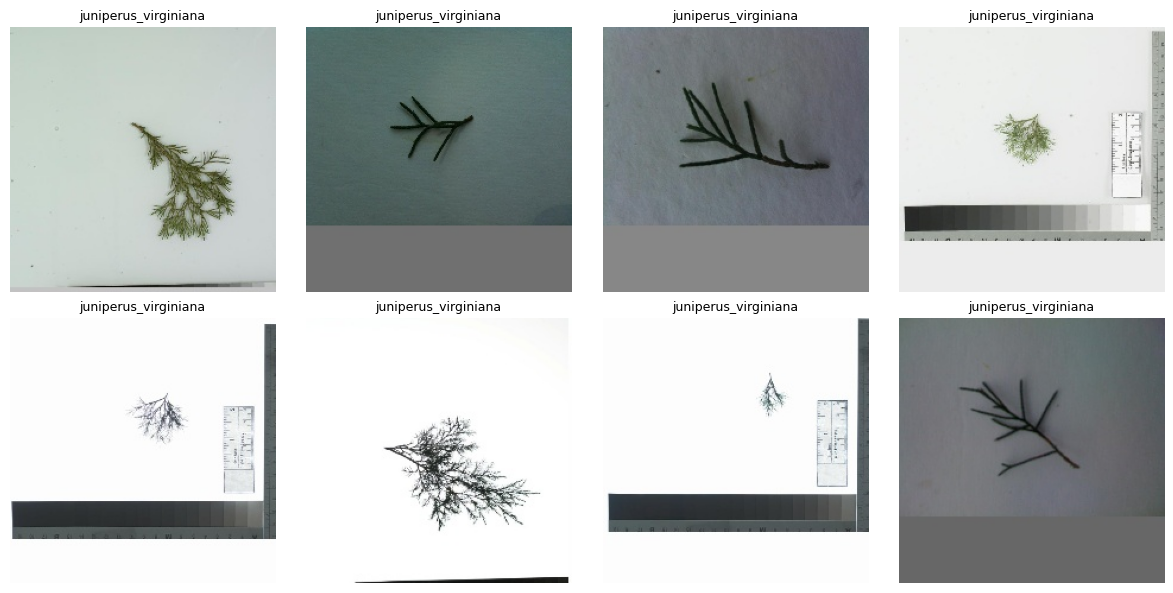

In [23]:
rare_class=class_counts.tail(5).index.tolist()
for label in rare_class:
    print(label,'count:',class_counts[label])
    show_samples(df_train[df_train['label']==label],n=min(8,class_counts[label]))

### (7) Frequent class

maclura_pomifera count: 353


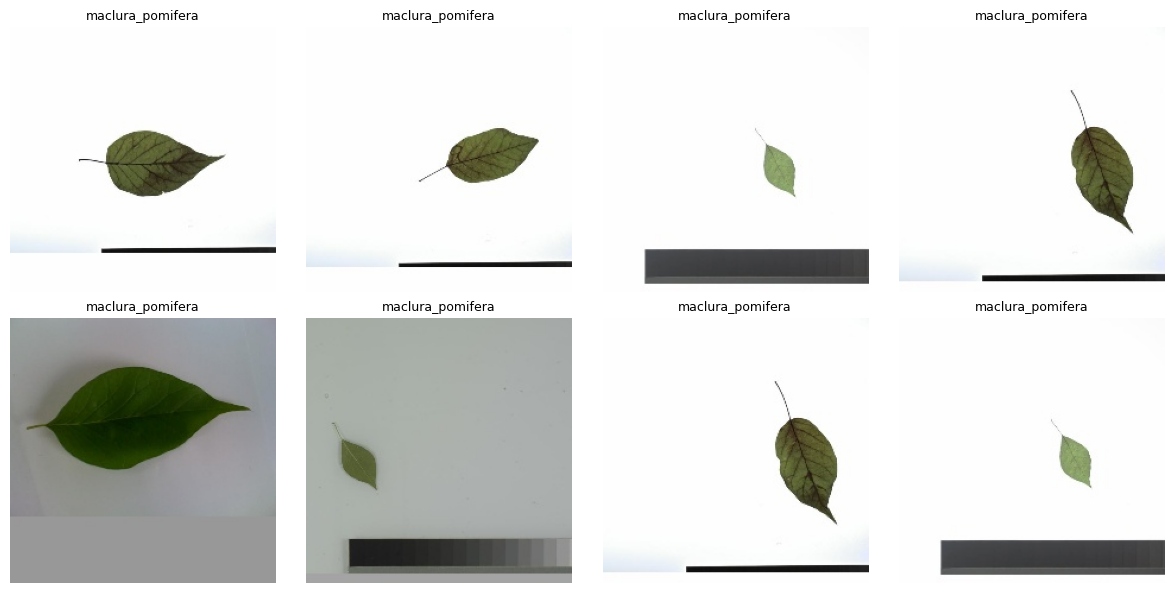

ulmus_rubra count: 235


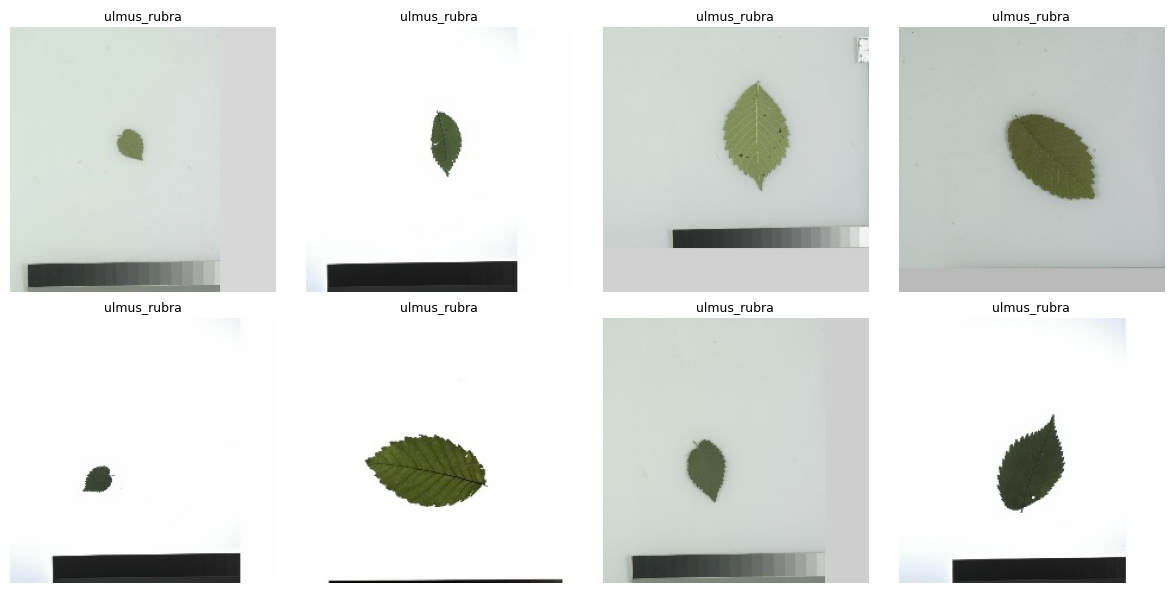

prunus_virginiana count: 223


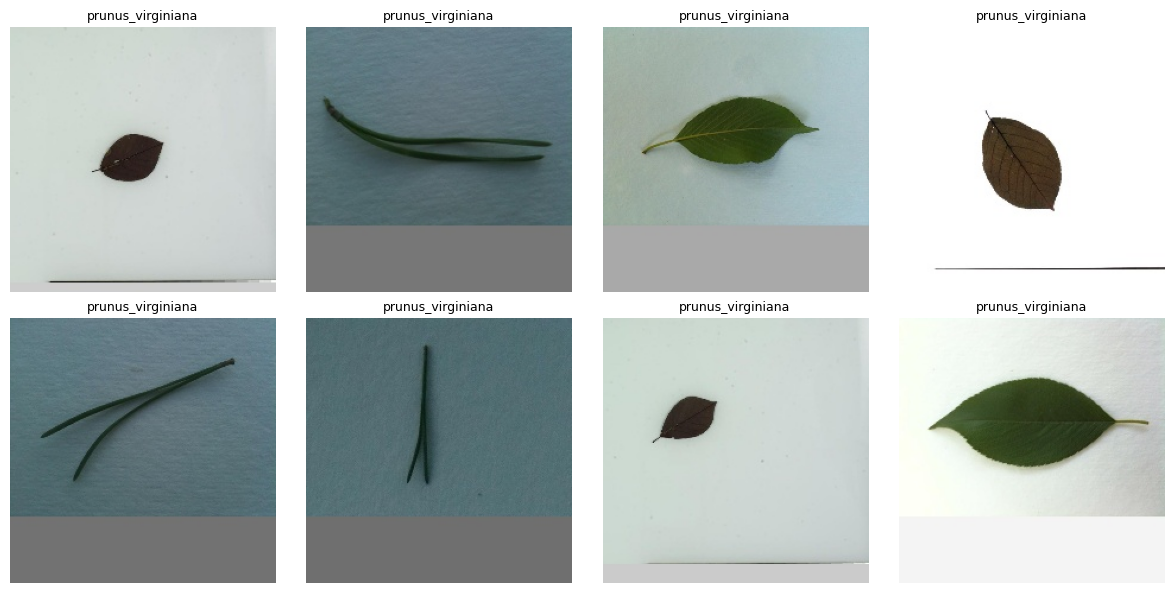

acer_rubrum count: 217


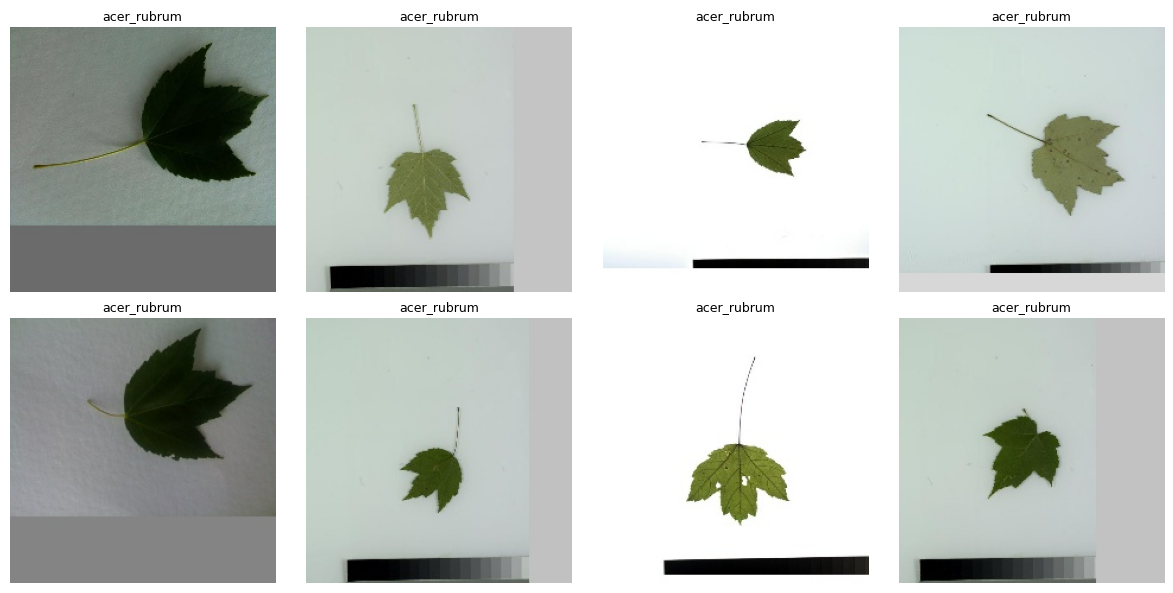

broussonettia_papyrifera count: 214


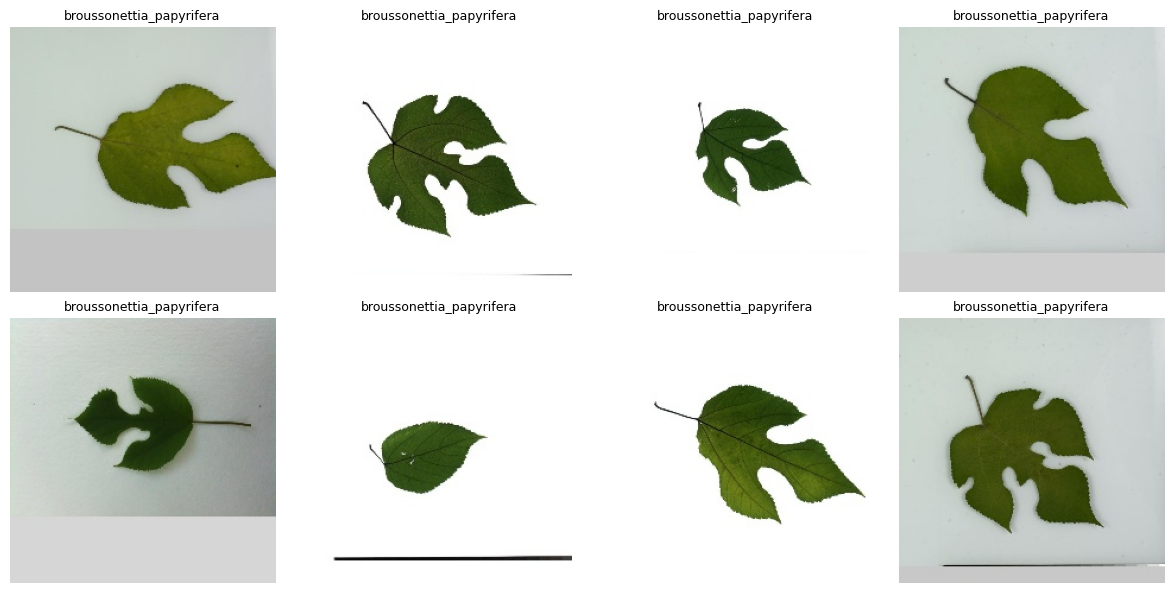

In [29]:
frequent_class=class_counts.head(5).index.tolist()
for label in frequent_class:
    print(label,'count:',class_counts[label])
    show_samples(df_train[df_train['label']==label],min(8,class_counts[label]))